In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


np.int64(0)

In [ ]:
df.head(10)
df.duplicated().sum()

In [8]:
df.select_dtypes(include='object').columns
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print()

mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']



In [15]:
import pandas as pd

df = pd.read_csv("Housing.csv")

In [16]:
yes_no_cols = ['mainroad','guestroom','basement',
               'hotwaterheating','airconditioning',
               'prefarea']

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [17]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [19]:
#training Model
X = df.drop('price', axis=1)
y = df['price']
print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [22]:
#Train-Test Split (80% &20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (436, 13)
X_test : (109, 13)
y_train: (436,)
y_test : (109,)


In [23]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [24]:
#Prediction
y_pred = lr_model.predict(X_test)
print(y_pred[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


In [25]:
#Comparison
print("Actual Prices:")
print(y_test.head())
print("Predicted Prices:")
print(y_pred[:5])

Actual Prices:
316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
Name: price, dtype: int64
Predicted Prices:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 970043.4039201637
RMSE: 1324506.9600914384
R² Score: 0.6529242642153185


In [27]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 1022560.0527522935
Random Forest RMSE: 1401496.8425384816
Random Forest R² Score: 0.6114024924156645


In [32]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[970043,1022560],
    'RMSE':[1324506,1401496],
    'R2 Score':[0.6529,0.6114]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,970043,1324506,0.6529
1,Random Forest,1022560,1401496,0.6114


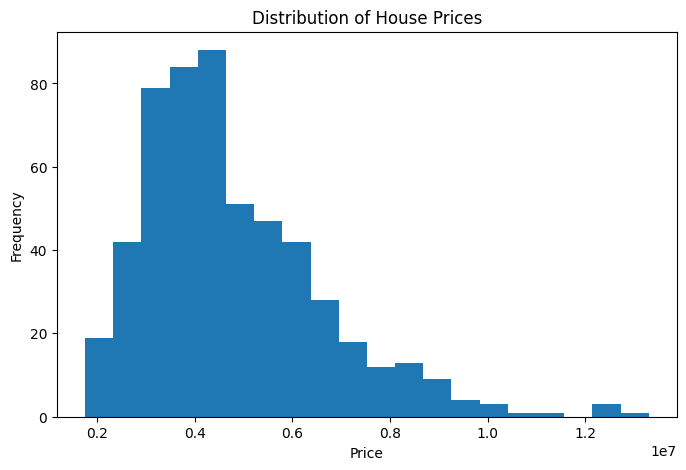

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

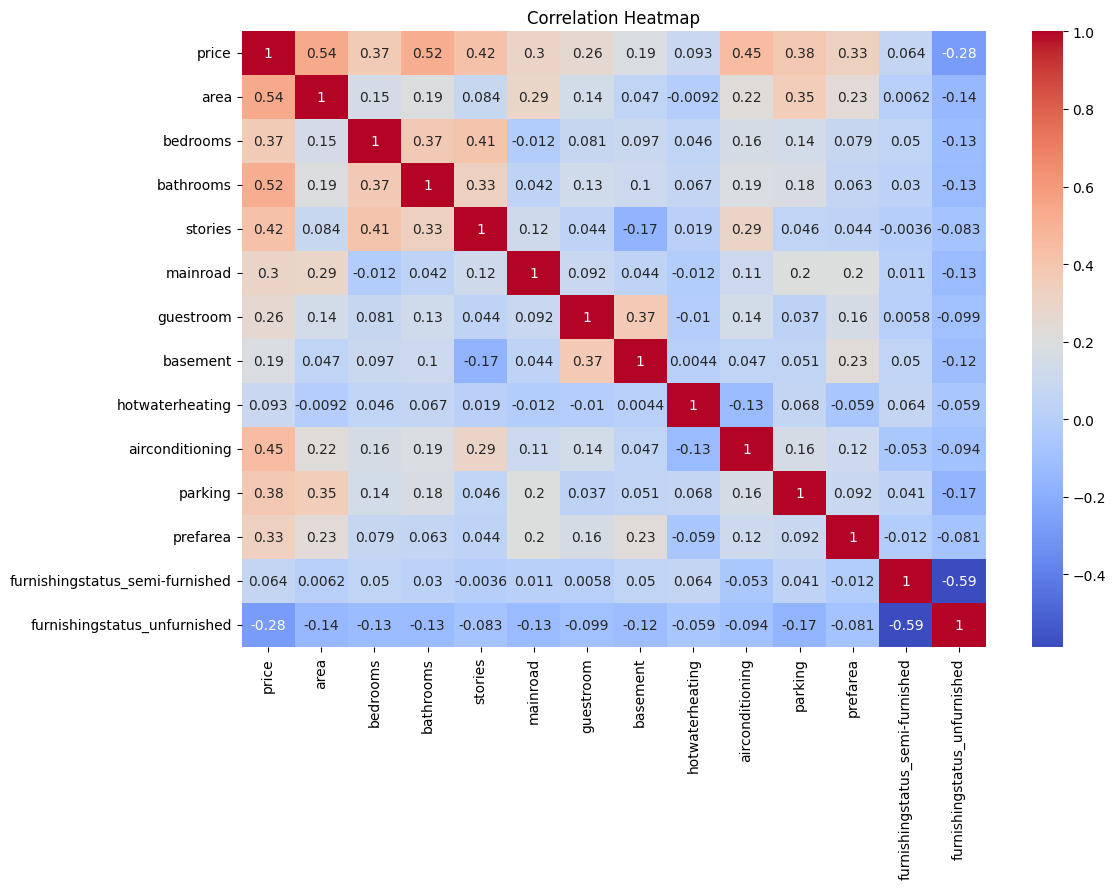

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

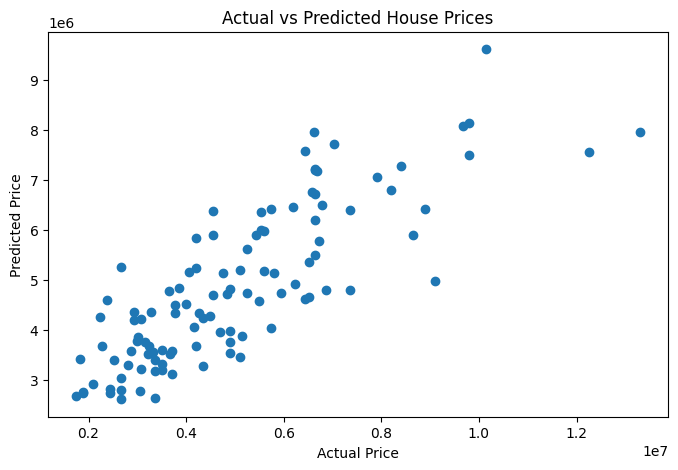

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
#SUMMARY
#The analysis showed that area and number of bathrooms have the strongest impact on house prices.
#Features such as air conditioning, parking, and additional stories also contribute to higher property values.
#The Linear Regression model achieved an R² score of 0.65, indicating reasonably good prediction performance.
#A notable observation was that houses with similar areas sometimes had different prices due to amenities and location-related factors.
#Based on these findings, real estate businesses should focus on larger homes with better facilities to maximize property value.